<table style="width:100%; float:center; background-color:#FFFFFF" align="left">
<tr>
<td style="text-align:left; background-color:#FFFFFF"></td>
<td style="text-align:right; background-color:#FFFFFF"><div>
<image src="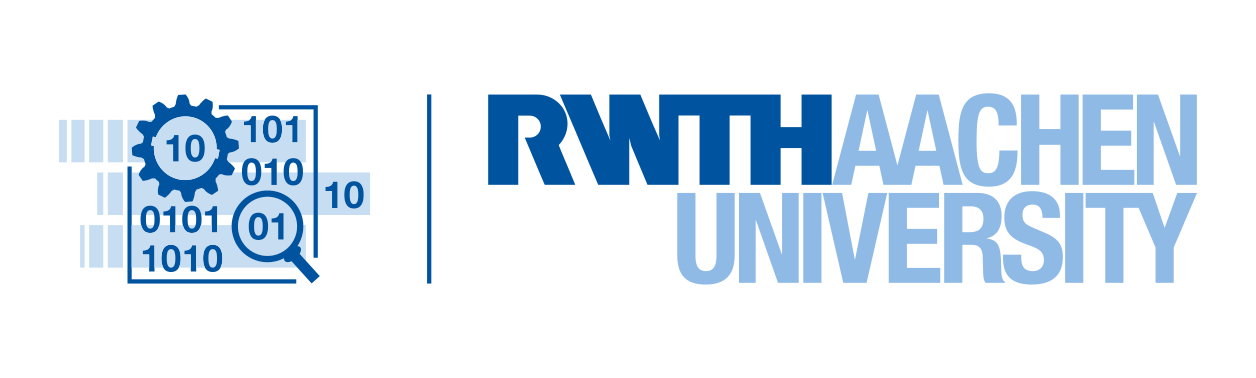" width="500">
    
</div>
</td></tr>
</table>

Prof. Dr. Sandra Geisler <br>
Soo-Yon Kim, Anastasiia Belova

June 16, 2025

<center>

<h1> Data Stream Management and Analysis <br />(Summer Term 2025)</h1>
    
<h1> Exercise 4</h1>
    
</center>

---
**Due until Monday, 30 June  at 8:00am.
As solutions, please submit the filled-in Jupyter notebook to moodle.  
Please do _not_ submit handwritten solutions! Your solutions should be submitted in groups of 4 students.**  
Solutions to this exercise will be presented on Friday, July 4.

---

### Group members: [Luyang Huang, 466716], [Feiyu Wang, 460101], [Yansong Liu, 453322], [Xingjian Tian, 436949]
#### Insert all group members by double-clicking on this cell.

---

## How to fill in the assignment

For coding tasks, you will find code cells with parts marked with comments in capital letters, e.g.: `# ADD IMPLEMENTATION ...` or `# REPLACE ...`    
Here, insert the required code into that part.

For written tasks, you will find Markdown cells marked with: `Please replace this text with your answer.`  
Here, you can double-click to edit the cell and use [Markdown](https://markdown.de/) to format the answer.
Mathematical expressions can be created via Latex. For this, enclose the expressions with \$.

## Task 1 (Speed Constraints) (4 pts)

You are given the following data stream:


| i | Timestamp $t$ | Value $x_i$ | 
|---|---------------|-------------|
| 1 | 1 | 10 |
| 2 | 2 | 11 |
| 3 | 3 | 12 |
| 4 | 5 | 15 |
| 5 | 6 | 14 |
| 6 | 8 | 15 |
| 7 | 9 | 20 |

1\.  Calculate all speed constraint violations for the given stream and the following parameterization: 

$W=2, S_{min} =-0.5, S_{max} =2$

We use $S_{x_j-x_i}$ to represent $(x_j - x_i) / (t_j-t_i), 0 < t_j-t_i \leq W=2$</br>
$S_{x_2-x_1}=1 \to \text{no violation}$</br>
$S_{x_3-x_1}=1 \to \text{no violation}$</br>
$S_{x_3-x_2}=1 \to \text{no violation}$</br>
$S_{x_4-x_3}=1.5 \to \text{no violation}$</br>
$S_{x_5-x_4}=-1 \to \text{violation}$</br>
$S_{x_6-x_5}=0.5 \to \text{no violation}$</br>
$S_{x_7-x_6}=2.5 \to \text{violation}$

2\.  Calculate the locally optimal repair for all violations.


In terms of $x_4$</br>
identify range: $x^{\min}_4 = 11, x^{\max}_4 = 16$</br>
identify candidates:$X^{\min}_4={13}, X^{\max}_4={10}$</br>
$x^{mid}_4 = median{10,13,15} = 13$</br>
Because $x^{mid}_4 \leq x^{\max}_4$ and $x^{\min}_4 \leq x^{mid}_4$, we have $x'_4 = x^{mid}_4 = 13$</br>
</br>
In terms of $x_7$</br>
identify range: $x^{\min}_7 = 14.5, x^{\max}_7 = 17$</br>
identify candidates: no candidate</br>
$x^{mid}_7 = median{20} = 20$</br>
Because $x^{\max}_7 < x^{mid}_7$, we have $x'_7 = x^{\max}_7 = 17$</br>

## Task 2 (Data Profiling and Data Cleaning) (4 pts)

Consider the open book data set "books.csv" extracted from Flickr (which you can find in moodle).

(1) Analyze manually or with the help of Talend Data Preparation (available in the moodle course room) which problems exist in the data set. Select four different problems, describe them and give an example. How could you analyze and detect these in a __streaming scenario__?

(2) For each of the selected problems, describe how you would clean the data given a streaming scenario. Optionally: implement the code to clean it in pandas.


In [3]:
import pandas as pd

df = pd.read_csv("books.csv", sep=";")
# shows top 30 rows
df.head(30)
# YOUR CODE HERE or written solution in cell below
# Problem 1: invalid format of year
df['Date of Publication'] = df['Date of Publication'].astype(str).str.extract(r'(\d{4})')
# Problem 2: missing author
df['Author'] = df['Author'].fillna(df['Contributors'])
# Problem 3: invalid value of place
df['Place of Publication'] = df['Place of Publication'].astype(str).str.split(';|:').str[0].str.strip()
# Problem 4: duplicate Identifier
df = df.drop_duplicates(subset=['Identifier'])
# Show result
df.head(30)

,Identifier,Edition Statement,Place of Publication,Date of Publication,Publisher,Title,Author,Contributors,Corporate Author,Corporate Contributors,Former owner,Engraver,Issuance type,Flickr URL,Shelfmarks
0,206,NaN,London,1879,S. Tinsley & Co.,Walter Forbes. [A novel.] By A. A,A. A.,"FORBES, Walter.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 12641.b.30.
1,216,NaN,London,1868,Virtue & Co.,All for Greed. [A novel. The dedication signed...,"A., A. A.","BLAZE DE BURY, Marie Pauline Rose - Baroness",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 12626.cc.2.
2,218,NaN,London,1869,"Bradbury, Evans & Co.",Love the Avenger. By the author of “All for Gr...,"A., A. A.","BLAZE DE BURY, Marie Pauline Rose - Baroness",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 12625.dd.1.
3,472,NaN,London,1851,James Darling,"Welsh Sketches, chiefly ecclesiastical, to the...","A., E. S.","Appleyard, Ernest Silvanus.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 10369.bbb.15.
4,480,"A new edition, revised, etc.",London,1857,Wertheim & Macintosh,"[The World in which I live, and my place in it...","A., E. S.","BROOME, John Henry.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 9007.d.28.
5,481,"Fourth edition, revised, etc.",London,1875,William Macintosh,"[The World in which I live, and my place in it...","A., E. S.","BROOME, John Henry.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 9006.ee.10.
6,519,NaN,London,1872,The Author,Lagonells. By the author of Darmayne (F. E. A....,"A., F. E.","ASHLEY, Florence Emily.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 12637.e.3.
7,667,NaN,pp. 40. G. Bryan & Co,NaN,NaN,"The Coming of Spring, and other poems. By J. A...","A., J.|A., J.","ANDREWS, J. - Writer of Verse",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 011652.g.73.
8,874,NaN,London],1676,NaN,"A Warning to the inhabitants of England, and L...",Remaʿ.,"ADAMS, Mary.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 11645.bb.42.
9,1143,NaN,London,1679,NaN,A Satyr against Vertue. (A poem: supposed to b...,"A., T.","OLDHAM, John.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 11602.ee.10.(2.)


Problem 1: Invalid format in "Date of Publication". Characters "[", "?" and "]" are included. And there is not only one exact year in this attribute. For example, "1847, 48 [1846-48]" and "[1897?]". By detecting how many digits describing the year.

Problem 2:Missing value in Author, but there are contributors. By detecting NaN to find this problem.

Problem 3:Combined value in "Place of Publication", like "London; Virtue & Yorston". Check correctness of city name to detect this problem.

Problem 4: Identifier 2956 appears twice in first 30 rows. Detect uniqueness of identifiers.

## Task 3 (Very Fast Decision Trees) (8 pts)

We want to learn a decision tree from an incoming stream of examples, which predicts if an incoming email is spam (**S**pam, **N**on spam) based on the following attributes:
- Suspicious **W**ords (<5, 5-10, >10)
- **H**TML email (**T**rue, **F**alse)
- **O**rigin (Well **K**nown, **U**nknown)

To build the decision tree, we use the Hoeffding Tree algorithm. For
the calculation of the Hoeffding bound, $\delta=0.5$ is used and splits are attempted at a leaf after it
accumulates $n_{min}=3$ new examples.
The split attributes are selected using information gain. At the beginning, the leaf counters $n_{i,j,k} = 0$
for all $i, j, k$.


| Example | Suspicious Words | HTML email | Origin | Class |
| :-:| :-: | :-: | :-: | :-: |
| $S_1$ | > 10 | true | unknown | spam |
| $S_2$ | 5-10 | true | well known | non spam |
| $S_3$ | > 10 | false | well known | spam |
| $S_4$ | < 5 | false | well known | non spam |
| $S_5$ | > 10 | true | well known | spam |
| $S_6$ | < 5 | true | well known | non spam |
| $S_7$ | < 5 | true | unknown | non spam |
| $S_8$ | 5-10 | false | unknown | no spam |
| $S_9$ | 5-10 | true | unknown | spam |
| $S_{10}$ | 5-10 | true | well known | no spam |
| $S_{11}$ | > 10 | true | well known | spam |
| $S_{12}$ | 5-10 | true | well known | no spam |
| $S_{13}$ | 5-10 | true | unknown | spam |
| $S_{14}$ | 5-10 | false | well known | no spam |


**Task:** Incrementally construct a Hoeffding tree based on the given examples.
Note down in detail, what you calculate and why.
You do not have to give the resulting tree.

Everytime a leaf node accumulates $n_{min}$ new examples and a split is attempted, give its count variables for all $n_{i,j,k} \neq 0$ in the following form:

| Leaf | Variable | Value |
| :-:| :-: | :-: |
| Node | $n_{i,j,k}$ | x |

You may abbreviate words with the bold letters from the text.
For example, if the root node collected five examples for spam with more than 10 suspicious words, the table entry would be:

| Leaf | Variable | Value |
| :-:| :-: | :-: |
| $r$ | $n_{W,>10,S}$ | 5|


At first we add example $S_1, S_2, S_3$
| Leaf | Variable | Value |
| :-:| :-: | :-: |
| $r$ | $n_{W,>10,S}$ | 2|
| $r$ | $n_{W,5-10,S}$ | 1|
| $r$ | $n_{H,T,S}$ | 2|
| $r$ | $n_{H,F,S}$ | 1|
| $r$ | $n_{O,K,S}$ | 2|
| $r$ | $n_{O,U,S}$ | 1|

where $S=\{S_1,S_2,S_3\}$. We have H(S)=0.918, IG(S,W)=0.918, IG(S,H)=0.252, IG(S,O)=0.252, $\epsilon=0.34$, IG(S,W) - IG(S,H) > $\epsilon$. So we split root by attribute W as follows:
| Leaf | Variable | Value |
| :-:| :-: | :-: |
| $l_1$ | $n_{H,T,S}$ | 1|
| $l_1$ | $n_{H,F,S}$ | 1|
| $l_1$ | $n_{O,K,S}$ | 1|
| $l_1$ | $n_{O,U,S}$ | 1|
| $l_2$ | $n_{H,T,S}$ | 1|
| $l_2$ | $n_{O,K,S}$ | 1|

where $n_{W,>10,S} \in l_1$, $n_{W,5-10,S} \in l_2$, $n_{W,<5,S} \in l_3$.</br>
Then we continue to add example $S_4,S_5,S_6,S_7$:
| Leaf | Variable | Value |
| :-:| :-: | :-: |
| $l_1$ | $n_{H,T,L_1}$ | 2|
| $l_1$ | $n_{H,F,L_1}$ | 1|
| $l_1$ | $n_{O,K,L_1}$ | 2|
| $l_1$ | $n_{O,U,L_1}$ | 1|
| $l_2$ | $n_{H,T,L_2}$ | 1|
| $l_2$ | $n_{O,K,L_2}$ | 1|
| $l_3$ | $n_{H,T,L_3}$ | 2|
| $l_3$ | $n_{H,F,L_3}$ | 1|
| $l_3$ | $n_{O,K,L_3}$ | 2|
| $l_3$ | $n_{O,U,L_3}$ | 1|

where $L_1=\{S_1,S_3,S_5\}$, $L_2=\{S2\}$, $L_3=\{S_4,S_6,S_7\}$. Though $|L_1| = |L_3| = 3$, split is unnessesary. Because all examples belong to spam or non-spam.

Then we add example $S_8,S_9$:
| Leaf | Variable | Value |
| :-:| :-: | :-: |
| $l_1$ | $n_{H,T,L_1}$ | 2|
| $l_1$ | $n_{H,F,L_1}$ | 1|
| $l_1$ | $n_{O,K,L_1}$ | 2|
| $l_1$ | $n_{O,U,L_1}$ | 1|
| $l_2$ | $n_{H,T,L_2}$ | 2|
| $l_2$ | $n_{H,F,L_2}$ | 1|
| $l_2$ | $n_{O,K,L_2}$ | 1|
| $l_2$ | $n_{O,U,L_2}$ | 2|
| $l_3$ | $n_{H,T,L_3}$ | 2|
| $l_3$ | $n_{H,F,L_3}$ | 1|
| $l_3$ | $n_{O,K,L_3}$ | 2|
| $l_3$ | $n_{O,U,L_3}$ | 1|

where $L_1=\{S_1,S_3,S_5\}$, $L_2=\{S_2,S_8,S_9\}$, $L_3=\{S_4,S_6,S_7\}$. We have H($L_2$)=0.918, IG($L_2$,H)=0.252, IG($L_2$,O)=0.252, $\epsilon=0.34$. We do not split it.

Then we continue to add example $S_{10}, S_{11}, S_{12}, S_{13}$:
| Leaf | Variable | Value |
| :-:| :-: | :-: |
| $l_1$ | $n_{H,T,L_1}$ | 3|
| $l_1$ | $n_{H,F,L_1}$ | 1|
| $l_1$ | $n_{O,K,L_1}$ | 3|
| $l_1$ | $n_{O,U,L_1}$ | 1|
| $l_2$ | $n_{H,T,L_2}$ | 5|
| $l_2$ | $n_{H,F,L_2}$ | 1|
| $l_2$ | $n_{O,K,L_2}$ | 3|
| $l_2$ | $n_{O,U,L_2}$ | 3|
| $l_3$ | $n_{H,T,L_3}$ | 2|
| $l_3$ | $n_{H,F,L_3}$ | 1|
| $l_3$ | $n_{O,K,L_3}$ | 2|
| $l_3$ | $n_{O,U,L_3}$ | 1|

where $L_1=\{S_1,S_3,S_5,S_{11}\}$, $L_2=\{S_2,S_8,S_9,S_{10},S_{12},S_{13}\}$, $L_3=\{S_4,S_6,S_7\}$. We have H($L_2$)=0.918, IG($L_2$,H)=0.109, IG($L_2$,O)=0.459, $\epsilon=0.24$. We split node $l2$ by attribute O:
| Leaf | Variable | Value |
| :-:| :-: | :-: |
| $l_1$ | $n_{H,T,L_1}$ | 3|
| $l_1$ | $n_{H,F,L_1}$ | 1|
| $l_1$ | $n_{O,K,L_1}$ | 3|
| $l_1$ | $n_{O,U,L_1}$ | 1|
| $l_3$ | $n_{H,T,L_3}$ | 2|
| $l_3$ | $n_{H,F,L_3}$ | 1|
| $l_3$ | $n_{O,K,L_3}$ | 2|
| $l_3$ | $n_{O,U,L_3}$ | 1|
| $l_4$ | $n_{H,T,L_4}$ | 3|
| $l_5$ | $n_{H,T,L_5}$ | 2|
| $l_5$ | $n_{H,F,L_5}$ | 1|

where $n_{O,K,S} \in l_4$, $n_{O,U,S} \in l_5$. Then we have$L_1=\{S_1,S_3,S_5,S_{11}\}$, $L_3=\{S_4,S_6,S_7\}$, $L_4=\{S_2,S_{10},S_{12}\}$, $L_5=\{S_8,S_9,S_{13}\}$.

Last, we add example $S_{14}$:
| Leaf | Variable | Value |
| :-:| :-: | :-: |
| $l_1$ | $n_{H,T,L_1}$ | 3|
| $l_1$ | $n_{H,F,L_1}$ | 1|
| $l_1$ | $n_{O,K,L_1}$ | 3|
| $l_1$ | $n_{O,U,L_1}$ | 1|
| $l_3$ | $n_{H,T,L_3}$ | 2|
| $l_3$ | $n_{H,F,L_3}$ | 1|
| $l_3$ | $n_{O,K,L_3}$ | 2|
| $l_3$ | $n_{O,U,L_3}$ | 1|
| $l_4$ | $n_{H,T,L_4}$ | 3|
| $l_4$ | $n_{H,F,L_4}$ | 1|
| $l_5$ | $n_{H,T,L_5}$ | 2|
| $l_5$ | $n_{H,F,L_5}$ | 1|

where $L_1=\{S_1,S_3,S_5,S_{11}\}$, $L_3=\{S_4,S_6,S_7\}$, $L_4=\{S_2,S_{10},S_{12},S_{14}\}$, $L_5=\{S_8,S_9,S_{13}\}$.

## Task 4 (Classification) (10 pts)

**Important Links for this task:**<br><br>
Anaconda
- https://www.anaconda.com/

ML package in python for data streams. Based on MOA:
- https://scikit-multiflow.github.io/
- https://scikit-multiflow.readthedocs.io/en/stable/api/api.html
- Agarwal generator is used to create the data stream for the task - https://scikit-multiflow.readthedocs.io/en/stable/api/generated/skmultiflow.data.AGRAWALGenerator.html#skmultiflow.data.AGRAWALGenerator .

Libraries for data sampling, evaluation metrics, visualization etc. :
- https://scikit-learn.org/stable/user_guide.html
- https://seaborn.pydata.org/

**Additional Notes**
* Remember to assign the `nominal_attributes` parameter for all the tree based classifiers.
<br><br>

1\. Create a stream using Aggarwal Generator and list the nominal features. Use random_state = 123. 

In [2]:
#Your Code
stream = AGRAWALGenerator(random_state=123, classification_function=0, balance_classes=False, perturbation=0.0)
nominal_attributes = [2, 3, 4, 5, 6, 7, 8]

# Synthetic data generator

#     Name  Agrawal              
#     Task  Binary classification
#  Samples  ∞                    
# Features  9                    
#  Outputs  1                    
#  Classes  2                    
#   Sparse  False                

# Configuration
# -------------
# classification_function  0    
#                    seed  123  
#         balance_classes  False
#            perturbation  0.0  

2\. Train incrementally (a) a Hoeffding Tree classifier with `Naive Bayes` prediction and (b) a Perceptron classifier on the first 30,000 samples from the stream. Compute the mean accuracy for both classifiers on the training data. Also implement a heatmap of the confusion matrices using the seaborn library.

Hoeffding Tree (Naive Bayes) mean accuracy: 0.9966
Perceptron mean accuracy: 0.8934


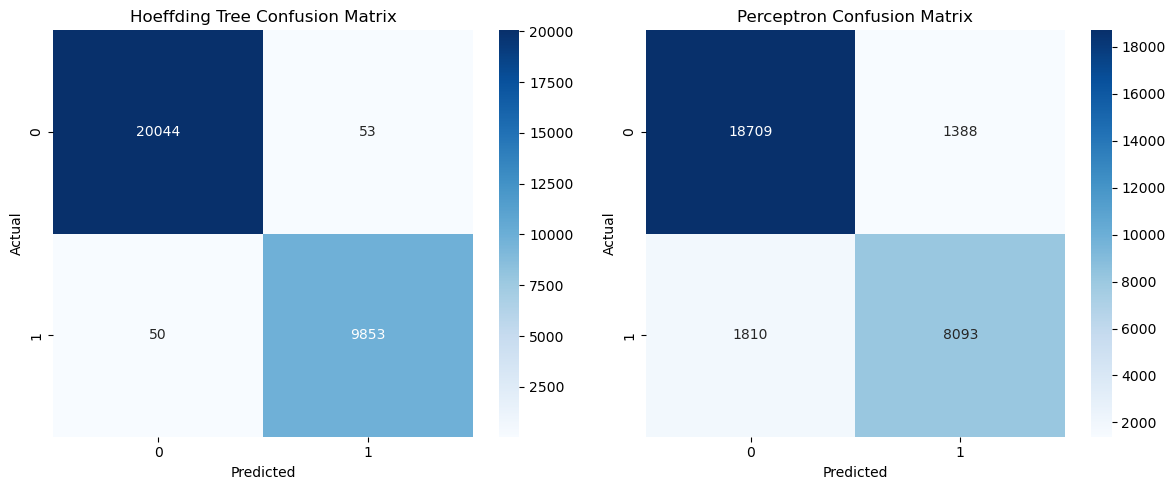

if Attribute 2 = 20.0:
  Leaf = Class 0 | {0: 446.0}
if Attribute 2 = 21.0:
  Leaf = Class 0 | {0: 512.0}
if Attribute 2 = 22.0:
  Leaf = Class 0 | {0: 503.0}
if Attribute 2 = 23.0:
  Leaf = Class 0 | {0: 496.0}
if Attribute 2 = 24.0:
  Leaf = Class 0 | {0: 489.0}
if Attribute 2 = 25.0:
  Leaf = Class 0 | {0: 497.0}
if Attribute 2 = 26.0:
  Leaf = Class 0 | {0: 513.0}
if Attribute 2 = 27.0:
  Leaf = Class 0 | {0: 513.0}
if Attribute 2 = 28.0:
  Leaf = Class 0 | {0: 474.0}
if Attribute 2 = 29.0:
  Leaf = Class 0 | {0: 471.0}
if Attribute 2 = 30.0:
  Leaf = Class 0 | {0: 501.0}
if Attribute 2 = 31.0:
  Leaf = Class 0 | {0: 475.0}
if Attribute 2 = 32.0:
  Leaf = Class 0 | {0: 493.0}
if Attribute 2 = 33.0:
  Leaf = Class 0 | {0: 527.0}
if Attribute 2 = 35.0:
  Leaf = Class 0 | {0: 480.0}
if Attribute 2 = 36.0:
  Leaf = Class 0 | {0: 445.0}
if Attribute 2 = 37.0:
  Leaf = Class 0 | {0: 498.0}
if Attribute 2 = 38.0:
  Leaf = Class 0 | {0: 488.0}
if Attribute 2 = 39.0:
  Leaf = Class 0 | {0: 

In [10]:
from skmultiflow.trees import HoeffdingTreeClassifier
from skmultiflow.neural_networks import PerceptronMask
import seaborn as sns # This library can be used for heatmap visualization of the confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

# Classifiers
classifier_tree = HoeffdingTreeClassifier(nominal_attributes=nominal_attributes, 
                                        leaf_prediction='nb')
classifier_perceptron = PerceptronMask()

# IMPLEMENTATION for training the classifiers
X_train = []
y_train = []
y_pred_tree = []
y_pred_perceptron = []

# First pass to get all classes
classes = []
for i in range(100):  # Small sample to detect classes
    X, y = stream.next_sample()
    classes.append(y[0])
classes = np.unique(classes)

# Train on first 30,000 samples
for i in range(30000):
    X, y = stream.next_sample()
    X_train.append(X[0])
    y_train.append(y[0])
    
    # Predict and train Hoeffding Tree
    y_pred_tree.append(classifier_tree.predict(X)[0])
    classifier_tree.partial_fit(X, y)
    
    # First train the Perceptron with classes, then predict
    if i == 0:
        classifier_perceptron.partial_fit(X, y, classes=classes)
    else:
        classifier_perceptron.partial_fit(X, y)
    y_pred_perceptron.append(classifier_perceptron.predict(X)[0])

# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
y_pred_tree = np.array(y_pred_tree)
y_pred_perceptron = np.array(y_pred_perceptron)

# Calculate accuracies
accuracy_tree = accuracy_score(y_train, y_pred_tree)
accuracy_perceptron = accuracy_score(y_train, y_pred_perceptron)

print(f"Hoeffding Tree (Naive Bayes) mean accuracy: {accuracy_tree:.4f}")
print(f"Perceptron mean accuracy: {accuracy_perceptron:.4f}")

# Confusion matrices
cm_tree = confusion_matrix(y_train, y_pred_tree)
cm_perceptron = confusion_matrix(y_train, y_pred_perceptron)

# Plot confusion matrices
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues')
plt.title('Hoeffding Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
sns.heatmap(cm_perceptron, annot=True, fmt='d', cmap='Blues')
plt.title('Perceptron Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# This prints the structure of the tree
print(classifier_tree.get_model_description())

3\. Test the classifiers trained in part 2 on 2000 unseen samples of the stream. Also calculate the mean accuracy on this test data and heatmap of the confusion matrices. How do the classifiers perform in comparison to the training data?

Hoeffding Tree test accuracy: 1.0000
Perceptron test accuracy: 0.3315


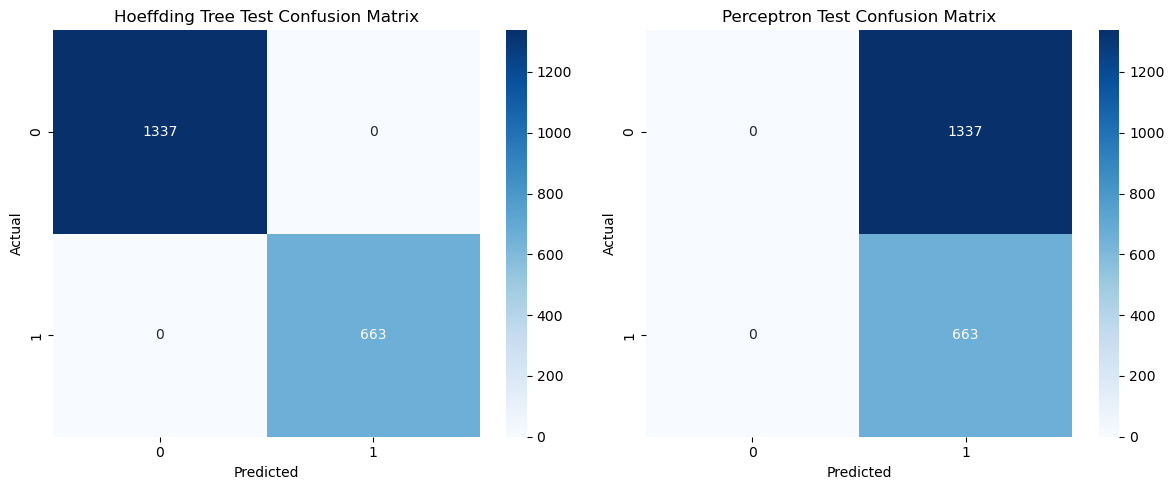

In [11]:
# IMPLEMENTATION for testing the classifiers
X_test = []
y_test = []
y_pred_tree_test = []
y_pred_perceptron_test = []

# Test on next 2000 unseen samples
for _ in range(2000):
    X, y = stream.next_sample()
    X_test.append(X[0])
    y_test.append(y[0])
    
    # Predict with both classifiers
    y_pred_tree_test.append(classifier_tree.predict(X)[0])
    y_pred_perceptron_test.append(classifier_perceptron.predict(X)[0])

# Convert to numpy arrays
X_test = np.array(X_test)
y_test = np.array(y_test)
y_pred_tree_test = np.array(y_pred_tree_test)
y_pred_perceptron_test = np.array(y_pred_perceptron_test)

# Calculate test accuracies
test_accuracy_tree = accuracy_score(y_test, y_pred_tree_test)
test_accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron_test)

print(f"Hoeffding Tree test accuracy: {test_accuracy_tree:.4f}")
print(f"Perceptron test accuracy: {test_accuracy_perceptron:.4f}")

# Test confusion matrices
cm_tree_test = confusion_matrix(y_test, y_pred_tree_test)
cm_perceptron_test = confusion_matrix(y_test, y_pred_perceptron_test)

# Plot test confusion matrices
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_tree_test, annot=True, fmt='d', cmap='Blues')
plt.title('Hoeffding Tree Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
sns.heatmap(cm_perceptron_test, annot=True, fmt='d', cmap='Blues')
plt.title('Perceptron Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

Hoeffding Tree has better performance in test dataset, while perceptron has wrose performance in test dataset.